# Is the 3-dart value function right?

The 3-dart MDP tracks which dart of a visit is being thrown, because a bust on dart 1
forfeits the other two. Its state is a triple:

$$(\text{score } u,\; \text{dart } d \in \{1,2,3\},\; \text{score the visit started on } s)$$

The fast solver in `darts/mdp_3turn.py` does **not** store a value for every one of those
triples. It claims that above certain score thresholds the third component is irrelevant,
and keeps a single number per `(score, dart)` instead. That claim is what makes 501 solve
in seconds rather than minutes, so it had better be true.

This notebook checks it two ways: against the original solver, which stores the whole
cube and assumes nothing, and by simulating the extracted policy.

## The claim

The visit's starting score $s$ enters the problem through exactly one channel: **a bust
resets your score to $s$ and ends the visit**. If no bust is reachable, $s$ never appears
in the backup, and it never appears in any successor either -- dart 3 hands over to a
*fresh* visit on $u - \text{dart}$, which does not reference $s$ at all.

A dart cannot bust from score $u$ if every possible dart score $j \le 60$ leaves a legal
remainder, i.e. if $u - 2 \ge 60$. So, with $M = 60$ the highest single-dart score:

| state | darts left in the visit | no bust reachable when |
|---|---|---|
| $(u, 3, s)$ | 1 | $u \ge M + 2 = 62$ |
| $(u, 2, s)$ | 2 | $u \ge 2M + 2 = 122$ |
| $(s, 1, s)$ | 3 | $s \ge 3M + 2 = 182$ |

The code derives these from `scores.max()` rather than hardcoding them, so a Quadro board
(where a single dart can score 80) automatically gets 82 / 162 / 242.

**This is a statement about the third argument only.** The value depends on the *current*
score $u$ enormously and non-monotonically -- 32 is a far better place to be than 33. That
is not in tension with anything here.

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..', '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'font.size': 9, 'legend.frameon': False,
})

from darts.transitions import transition_arrays
from darts.mdp_3turn import _compute_3turn_values, ThreeDartMDP

G = 200          # enough to cover every visit-start that can reach a score of 62
tr = transition_arrays(512, 15.0, point_stride=8)
P, CP, S = tr['probs'], tr['checkout_probs'], tr['allowed_scores']
M = int(S.max())
print(f'{len(tr["points"])} aiming points, highest single-dart score M = {M}')
print(f'predicted thresholds: dart 3 >= {M+2}, dart 2 >= {2*M+2}, whole visit >= {3*M+2}')

1893 aiming points, highest single-dart score M = 60
predicted thresholds: dart 3 >= 62, dart 2 >= 122, whole visit >= 182


## The reference: every state, no assumptions

`_compute_3turn_values` is the original Numba solver. It carries a separate value for
every `(score, dart, visit start)` triple and sweeps them all to convergence. It is slow,
which is the whole reason the fast solver exists, but it assumes nothing.

In [2]:
import time
cube = np.zeros((G + 2, 3, G + 2))
t0 = time.perf_counter()
_compute_3turn_values(cube, P, CP, S, G, 1e-13)
print(f'reference solver: {time.perf_counter() - t0:.0f}s for {(G-1)*(G+1)*3:,} states')

reference solver: 25s for 119,997 states


## Measuring the dependence

For each score $u$ and dart $d$, look at $V(u, d, s)$ across every visit-start $s$ from
which that state is reachable, and take the range. If the claim holds this is exactly zero
above the threshold and non-zero below it.

In [3]:
def spread(u, dart):
    '''Range of V(u, dart, s) over every visit start s that can reach (u, dart).'''
    thrown = dart - 1                       # darts already thrown this visit
    lo, hi = u, min(G, u + thrown * M)      # each can have scored at most M
    vals = [cube[u, dart - 1, s] for s in range(lo, hi + 1)
            if cube[u, dart - 1, s] != 0]
    return (max(vals) - min(vals), len(vals)) if vals else (0.0, 0)

rows = []
for dart, scores in [(3, [10, 20, 40, 55, 58, 59, 60, 61, 62, 63, 70, 100, 150]),
                     (2, [60, 100, 118, 119, 120, 121, 122, 123, 130, 160])]:
    for u in scores:
        sp, n = spread(u, dart)
        rows.append({'dart': dart, 'score': u, 'n visit starts': n,
                     'spread of V': sp,
                     'above threshold': u >= (M + 2 if dart == 3 else 2 * M + 2)})
pd.DataFrame(rows).set_index(['dart', 'score'])

n visit starts   spread of V  above threshold
dart score                                               
3    10                121  2.331481e-01            False
     20                121  2.678905e-02            False
     40                121  6.286542e-05            False
     55                121  0.000000e+00            False
     58                121  2.460781e-05            False
     59                121  0.000000e+00            False
     60                121  3.617693e-02            False
     61                121  8.658496e-11            False
     62                121  0.000000e+00             True
     63                121  0.000000e+00             True
     70                121  0.000000e+00             True
     100               101  0.000000e+00             True
     150                51  0.000000e+00             True
2    60                 61  1.985165e-02            False
     100                61  5.839633e-06            False
     118                61  1.780919e-06            False
     119                61  0.000000e+00            False
     120                61  2.631832e-03            False
     121                61  0.000000e+00            False
     122                61  0.000000e+00             True
     123                61  0.000000e+00             True
     130                61  0.000000e+00             True
     160                41  0.000000e+00             True

Exactly as predicted: large below the threshold, identically zero at and above it.

Score 61 on dart 3 is a nice edge case. A bust *is* reachable there -- a 60 would leave 1 --
so in principle the value should depend on the visit start. It comes out at ~1e-10, because
the optimal aim from 61 essentially never lands on exactly 60. The dependence is real but
the optimal policy refuses to expose itself to it.

Printed across every visit start, the boundary is flat to every digit:

In [4]:
for u in [61, 62]:
    vals = [(s, -cube[u, 2, s]) for s in range(u, min(G, u + 2 * M) + 1, 12)]
    print(f'u={u}: ' + '  '.join(f's={s}:{v:.5f}' for s, v in vals))

u=61: s=61:7.35103  s=73:7.35103  s=85:7.35103  s=97:7.35103  s=109:7.35103  s=121:7.35103  s=133:7.35103  s=145:7.35103  s=157:7.35103  s=169:7.35103  s=181:7.35103
u=62: s=62:7.43721  s=74:7.43721  s=86:7.43721  s=98:7.43721  s=110:7.43721  s=122:7.43721  s=134:7.43721  s=146:7.43721  s=158:7.43721  s=170:7.43721  s=182:7.43721


## For contrast: the current score matters enormously

Nothing above says the value function is flat. It is extremely sensitive to the score you
are actually on -- which is the whole point of the endgame.

score,32,33,40,41,50,51,60,61,62,63
expected darts,5.3375,6.5126,5.6834,6.5863,6.5897,6.5926,6.8995,7.351,7.4372,7.5035


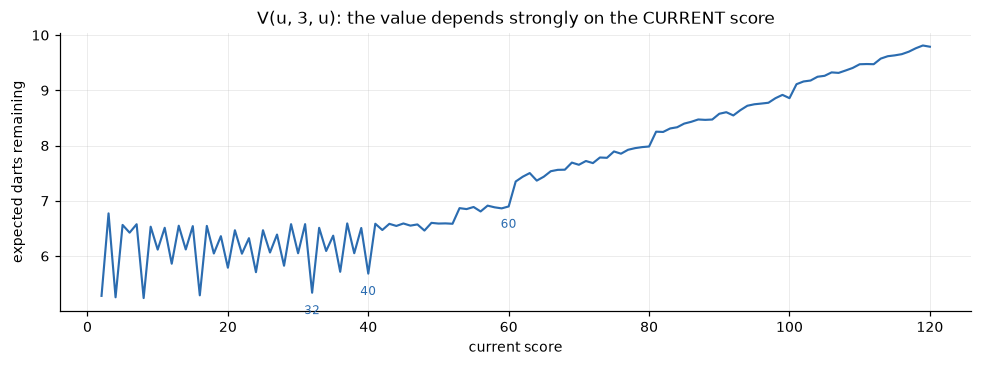

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.4))
xs = np.arange(2, 121)
ax.plot(xs, [-cube[u, 2, u] for u in xs], color='#2b6cb0', lw=1.4)
for u in [32, 40, 60]:
    ax.annotate(str(u), (u, -cube[u, 2, u]), textcoords='offset points',
                xytext=(0, -14), ha='center', fontsize=8, color='#2b6cb0')
ax.set_xlabel('current score'); ax.set_ylabel('expected darts remaining')
ax.set_title('V(u, 3, u): the value depends strongly on the CURRENT score')
fig.tight_layout()

pd.DataFrame({'score': [32, 33, 40, 41, 50, 51, 60, 61, 62, 63],
              'expected darts': [round(-cube[u, 2, u], 4)
                                 for u in [32, 33, 40, 41, 50, 51, 60, 61, 62, 63]]}
             ).set_index('score').T

## The fast solver against the reference

The real test: does the cached representation reproduce every state of the full cube?

In [6]:
fast = ThreeDartMDP(P, CP, S, G).solve(tol=1e-13)

worst_v1 = max(abs(fast.V1[s] - cube[s, 0, s]) for s in range(2, G + 1))
worst_tab, n_checked = 0.0, 0
for s in range(2, G + 1):
    for u in range(max(2, s - 2 * M), s):
        if u >= fast.u3_indep:
            worst_tab = max(worst_tab, abs(fast.V3tab[u] - cube[u, 2, s])); n_checked += 1
    for u in range(max(2, s - M), s):
        if u >= fast.u2_indep:
            worst_tab = max(worst_tab, abs(fast.V2tab[u] - cube[u, 1, s])); n_checked += 1

print(f'worst |V1 difference| over {G-1} start-of-visit states:      {worst_v1:.3e}')
print(f'worst |cached table - full cube| over {n_checked:,} states:  {worst_tab:.3e}')

worst |V1 difference| over 199 start-of-visit states:      2.016e-13
worst |cached table - full cube| over 12,330 states:  4.263e-14


## An end-to-end check: play the policy

Values and policies can agree with each other and still both be wrong. The independent
check is to play legs under the extracted policy, sampling from the model's own transition
probabilities, and see whether the mean number of darts matches the value function.

In [7]:
rows = []
for score in [200, 170, 101, 61, 40, 2]:
    darts, _ = fast.simulate(n_legs=20000, score=score, seed=1)
    se = darts.std() / np.sqrt(len(darts))
    rows.append({'score': score, 'MDP value': round(fast.expected_darts(score), 4),
                 'simulated mean': round(darts.mean(), 4), 'MC std error': round(se, 4),
                 'z': round((darts.mean() - fast.expected_darts(score)) / se, 2)})
pd.DataFrame(rows).set_index('score')

,MDP value,simulated mean,MC std error,z
score,,,,
200,13.5400,13.5620,0.0389,0.57
170,12.2238,12.2169,0.0372,-0.19
101,9.1074,9.0928,0.0359,-0.41
61,7.3637,7.3704,0.0352,0.19
40,5.6838,5.6492,0.0364,-0.95
2,5.2805,5.2527,0.0333,-0.83


## Conclusion

* The visit-start independence holds exactly above 62 / 122 / 182, and the thresholds are
  derived from the board rather than assumed.
* The fast solver reproduces the full state space to ~1e-13.
* Simulating the extracted policy recovers the value function to within Monte Carlo error.

The same argument is what makes the two-player game tractable, where the analogous
ordering is by the *total* of the two players' scores.